In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 2** - Mystery ML Model (2D)

A black-box model taking two inputs and returning a log-likelihood score. 
- Goal is to maximise on a noisy, multi-peaked surface.

- **Input** - 2D array
- **Optimisation Goal** - Maximise  
- **All-time best:** 0.6296 at [0.701, 0.958] (Week 10)

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 2
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy')

# New data for Week 10 (Function 2)
X_w10_new_point = np.array([0.701022, 0.958065], dtype=np.float64)
Y_w10_new_point = np.array([0.6296212596032481], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w10_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w10_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 2: ", X_unique)
print("Updated Outputs (Y) - Function 2: ", Y_updated)

Updated Inputs (X) - Function 2:  [[0.14269907 0.34900513]
 [0.33864816 0.21386725]
 [0.34174959 0.02869772]
 [0.43816606 0.68501826]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.638512   0.01429   ]
 [0.656253   0.988919  ]
 [0.66579958 0.12396913]
 [0.688961   0.010598  ]
 [0.69697    0.070707  ]
 [0.701022   0.958065  ]
 [0.70263656 0.9265642 ]
 [0.703106   0.923905  ]
 [0.730653   0.213258  ]
 [0.736899   0.001     ]
 [0.84527543 0.71112027]
 [0.871256   0.999348  ]
 [0.87779099 0.7786275 ]
 [0.998312   0.002851  ]]
Updated Outputs (Y) - Function 2:  [-0.06562362 -0.01385762  0.03874902  0.24461934  0.21496451  0.02310555
  0.29668333  0.51976639  0.53899612  0.55966119  0.49414992  0.62962126
  0.61120522  0.59071744  0.48809387  0.37180079  0.29399291  0.05410069
  0.42058624 -0.08088786]


## Output Analysis
- This week I got an all-time best result 0.6296 at [0.701, 0.958], which is higher than w9 output of 0.5907.

    - Consequtive improvements in the high x2 region: 0.5907 to 0.6296. The EI exploration strategy is working. 
    - A common trend was that both points share a similar x1 around 0.701, while x2 has moved from 0.924 to 0.958. 
        - The score continues to rise as x2 increases, suggesting the peak may be at a very high x2 value.

- **Real-world implications**: In log likelihood optimisation, a score increasing consistently as one parameter approaches its boundary often indicates the true maximium is at or near that boundary.

    - This is a known phenomenon in parameter estimation where certain configurations become increasingly stable or likely as one input reaches an extreme.

- **Model Clues and Future Exploration**: the risk now is over-fixating two consequetive improvements in this narrow corridor could lead to premature exploitation of what may be a local trend rather than the global peak.

## **Bayesian Optimisation**

- **Model**: Matern (nu=2.5) + Whitekernel with Yeo-Johnson transformation 
    - Kernel held constant, the consecutive improvements validate it.

- **Key Change**: Deliberately widening th esearch slightly to std=0.03.
    - A slightly wider grid lets the GP test whether the score continues to improve or plateaus, giving me a genuine shape information rather than just incrementally climbing the same slope.

- **Limitation**: With only 2D, widening slighly is low risk. The main concern is that the function is noisey and a singel higher reading could be variance rather than a true peak.
    - EI with a moderate xi protects against this by requiring a meaningful expected improvement, not just any increase.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(length_scale=0.1,
    length_scale_bounds=(1e-2, 1e2),
    nu=2.5) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=False)

model.fit(X_unique, Y_transformed)

Original Y: [-0.06562362 -0.01385762  0.03874902  0.24461934  0.21496451  0.02310555
  0.29668333  0.51976639  0.53899612  0.55966119  0.49414992  0.62962126
  0.61120522  0.59071744  0.48809387  0.37180079  0.29399291  0.05410069
  0.42058624 -0.08088786]
Transformed Y: [-1.49340919 -1.32241041 -1.14110424 -0.35739239 -0.47748534 -1.19583372
 -0.14075686  0.86995553  0.96326521  1.0646232   0.74716857  1.41606254
  1.32231153  1.21905342  0.71839343  0.18471937 -0.15213176 -1.08672682
  0.40421297 -1.54251504]


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- **Strategy**: EI with xi = 0.01, std slightly widended to 0.03.
    - Reasoning: Widening std from 0.01 to 0.03 deliberately introduces more diversity around w10 best. 
    - This conscious anti-overfitting move, two consecutive gains in a narrow corridoe risk the search tunelling into a local ridge.
        - EI with xi = 0.01 still anchors to beating 0.6296, but wider candidate cloud means the acquisition function must genuinely preger the w10 region over alternatives rather than having no alternative to choose from.

- **Sample size**: 10,000 points (80% focused at std=0.03, 20% uniform).

In [4]:
def expected_improvement(X, model, y_max, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)

    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

w10_best = np.array([0.701022, 0.958065])

# Slightly wider std=0.03 to avoid over-fixating on the narrow corridor
x_focused = np.random.normal(loc=w10_best, scale=0.03, size=(8000, 2))
x_uniform = np.random.uniform(0, 1, size=(2000, 2))
x_grid = np.clip(np.vstack([x_focused, x_uniform]), 0, 1)

y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)
next_query = x_grid[np.argmax(ei_values)]

print(f'W10 best: {w10_best}')
print(f'Strategic Week 11 Query (Function 2): {next_query[0]:.6f}-{next_query[1]:.6f}')

W10 best: [0.701022 0.958065]
Strategic Week 11 Query (Function 2): 0.677237-0.943693


## **Visualisation**

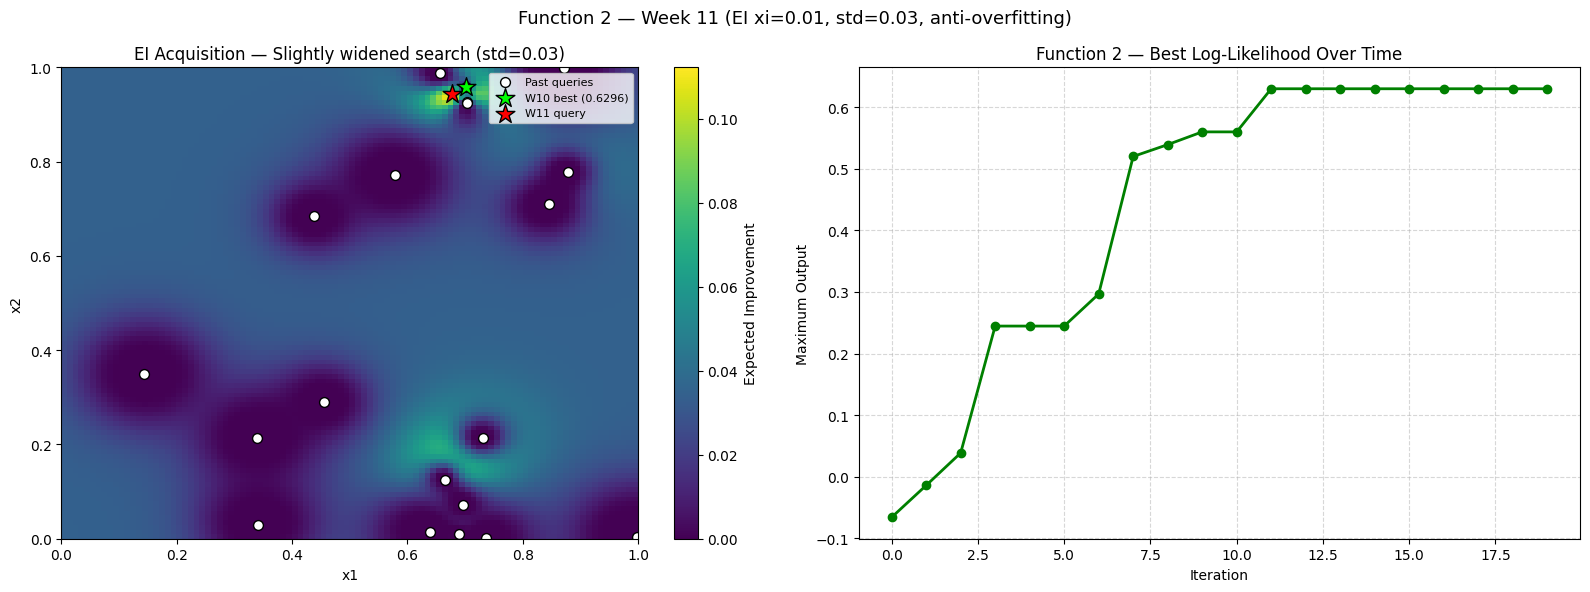

In [5]:
res = 100
X1, X2 = np.meshgrid(np.linspace(0, 1, res), np.linspace(0, 1, res))
X_plot = np.vstack([X1.ravel(), X2.ravel()]).T
ei_plot = expected_improvement(X_plot, model, y_max, xi=0.01).reshape(res, res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sc = ax1.imshow(ei_plot, extent=[0,1,0,1], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(sc, ax=ax1, label='Expected Improvement')
ax1.scatter(X_unique[:,0], X_unique[:,1], c='white', edgecolors='black', s=50, label='Past queries')
ax1.scatter(w10_best[0], w10_best[1], c='lime', marker='*', s=200, edgecolors='black', zorder=6, label='W10 best (0.6296)')
ax1.scatter(next_query[0], next_query[1], c='red', marker='*', s=200, edgecolors='black', zorder=7, label='W11 query')
ax1.set_title('EI Acquisition — Slightly widened search (std=0.03)')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.legend(fontsize=8)

running_max = np.maximum.accumulate(Y_updated)
ax2.plot(running_max, marker='o', color='green', linewidth=2)
ax2.set_title('Function 2 — Best Log-Likelihood Over Time')
ax2.set_xlabel('Iteration'); ax2.set_ylabel('Maximum Output')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 2 — Week 11 (EI xi=0.01, std=0.03, anti-overfitting)', fontsize=13)
plt.tight_layout()
plt.show()